# Week 4 — Tuesday: SIFT, SURF & ORB Descriptors

## Learning Objectives
- Understand scale-space and multi-scale feature detection
- Learn SIFT (Scale-Invariant Feature Transform)
- Explore SURF (Speedup Robust Features)
- Master ORB (Oriented FAST and Rotated BRIEF)
- Compare descriptor approaches

## Key Concepts
1. **Scale Space**: Difference of Gaussians (DoG)
2. **SIFT**: Robust, slow, patented (mostly free now)
3. **SURF**: Faster SIFT alternative
4. **ORB**: Free, fast, modern approach (FAST + BRIEF)
5. **Descriptor vectors**: Matching between images

## Section 1: Scale Space Theory

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (14, 8)

### 1.1 Gaussian Pyramid & Difference of Gaussians

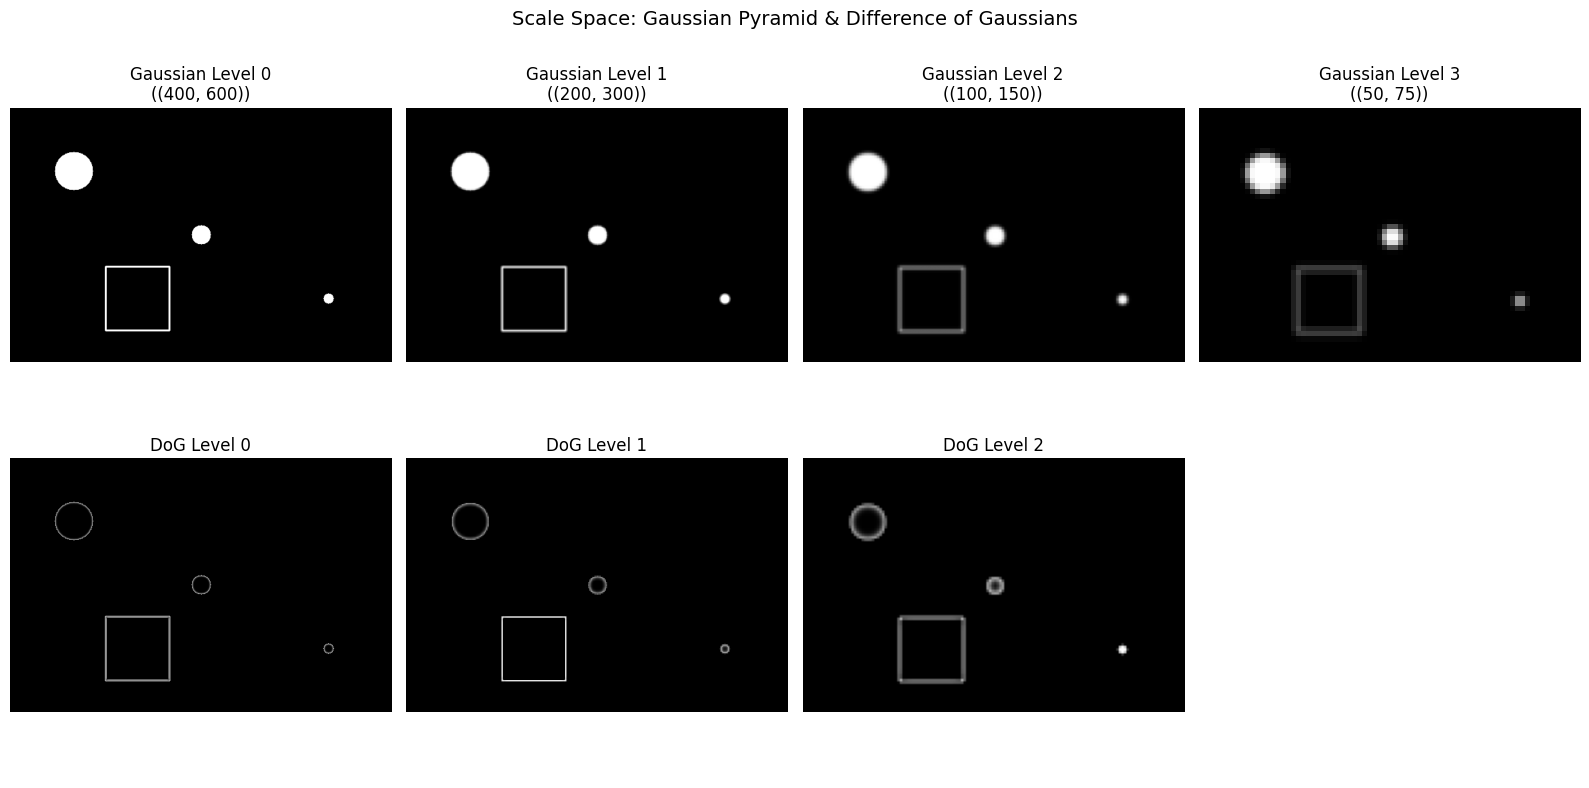

Gaussian Pyramid Levels: 4
Laplacian Pyramid Levels: 3


In [2]:
# Create a test image with features at different scales
img = cv2.imread('sample.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    # Create synthetic test image
    img = np.zeros((400, 600), dtype=np.uint8)
    cv2.circle(img, (100, 100), 30, 255, -1)  # Large feature
    cv2.circle(img, (300, 200), 15, 255, -1)  # Medium feature
    cv2.circle(img, (500, 300), 8, 255, -1)   # Small feature
    cv2.rectangle(img, (150, 250), (250, 350), 255, 2)

# Build Gaussian pyramid
gaussian_pyramid = [img]
for i in range(3):
    img_down = cv2.pyrDown(gaussian_pyramid[-1])
    gaussian_pyramid.append(img_down)

# Build Laplacian pyramid (Difference of Gaussians)
lap_pyramid = []
for i in range(len(gaussian_pyramid) - 1):
    size = (gaussian_pyramid[i].shape[1], gaussian_pyramid[i].shape[0])
    gp_expanded = cv2.pyrUp(gaussian_pyramid[i + 1], dstsize=size)
    lap = cv2.subtract(gaussian_pyramid[i], gp_expanded)
    lap_pyramid.append(lap)

# Visualize
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    if i < len(gaussian_pyramid):
        axes[0, i].imshow(gaussian_pyramid[i], cmap='gray')
        axes[0, i].set_title(f'Gaussian Level {i}\n({gaussian_pyramid[i].shape})')
        axes[0, i].axis('off')

for i in range(3):
    if i < len(lap_pyramid):
        axes[1, i].imshow(lap_pyramid[i], cmap='gray')
        axes[1, i].set_title(f'DoG Level {i}')
        axes[1, i].axis('off')

axes[1, 3].axis('off')
plt.suptitle('Scale Space: Gaussian Pyramid & Difference of Gaussians', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Gaussian Pyramid Levels: {len(gaussian_pyramid)}")
print(f"Laplacian Pyramid Levels: {len(lap_pyramid)}")

## Section 2: SIFT (Scale-Invariant Feature Transform)

SIFT available in OpenCV


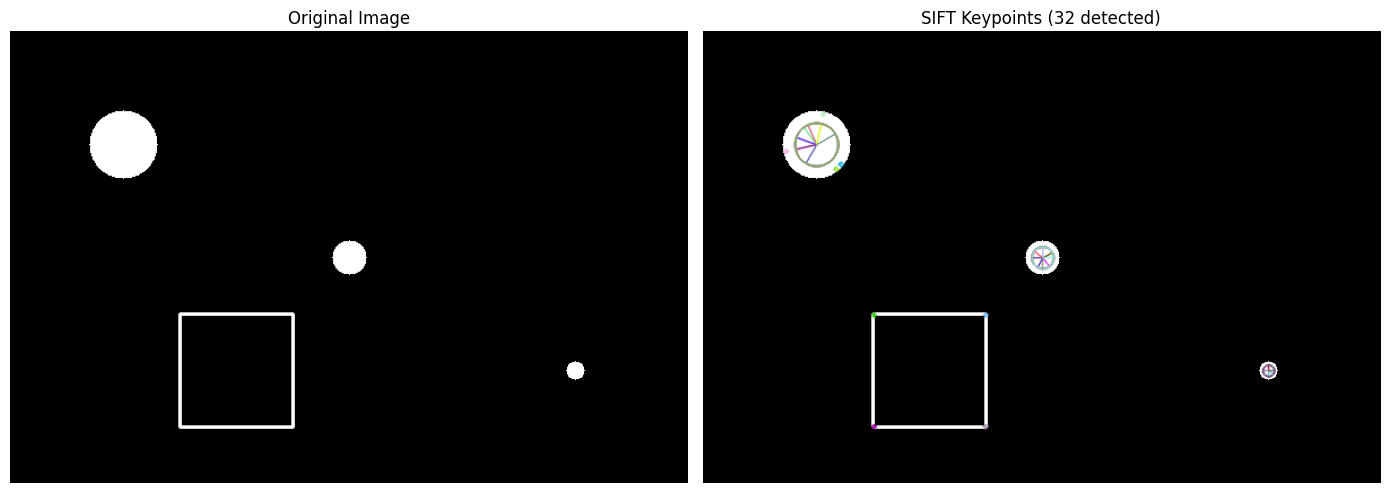


SIFT Results:
  Keypoints: 32
  Descriptor size: (32, 128)
  Descriptor type: float32
  Descriptor range: [0.00, 161.00]


In [3]:
# SIFT in OpenCV (available in contrib module, or use built-in SIFT)
# Note: SIFT patent expired, now free to use

try:
    sift = cv2.SIFT_create()
    print("SIFT available in OpenCV")
except AttributeError:
    print("SIFT not available - using ORB instead")
    sift = None

# Test on scaled image
test_img = gaussian_pyramid[0]  # Original size

if sift is not None:
    # Find keypoints and descriptors
    keypoints, descriptors = sift.detectAndCompute(test_img, None)
    
    # Draw keypoints
    sift_img = cv2.drawKeypoints(test_img, keypoints, None,
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(test_img, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(sift_img, cv2.COLOR_BGR2RGB) if len(sift_img.shape) == 3 else sift_img, cmap='gray')
    axes[1].set_title(f'SIFT Keypoints ({len(keypoints)} detected)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"\nSIFT Results:")
    print(f"  Keypoints: {len(keypoints)}")
    print(f"  Descriptor size: {descriptors.shape if descriptors is not None else 'None'}")
    if descriptors is not None:
        print(f"  Descriptor type: {descriptors.dtype}")
        print(f"  Descriptor range: [{descriptors.min():.2f}, {descriptors.max():.2f}]")

## Section 3: SURF (Speedup Robust Features)

In [4]:
# SURF using OpenCV (requires opencv-contrib-python)
try:
    surf = cv2.xfeatures2d.SURF_create(hessianThreshold=400)
    print("SURF available")
except:
    print("SURF not available - install opencv-contrib-python")
    surf = None

# Test SURF
if surf is not None:
    keypoints_surf, descriptors_surf = surf.detectAndCompute(test_img, None)
    
    surf_img = cv2.drawKeypoints(test_img, keypoints_surf, None,
                                 flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(test_img, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(surf_img, cv2.COLOR_BGR2RGB) if len(surf_img.shape) == 3 else surf_img, cmap='gray')
    axes[1].set_title(f'SURF Keypoints ({len(keypoints_surf)} detected)')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    
    print(f"\nSURF Results:")
    print(f"  Keypoints: {len(keypoints_surf)}")
    print(f"  Descriptor size: {descriptors_surf.shape if descriptors_surf is not None else 'None'}")

SURF not available - install opencv-contrib-python


## Section 4: ORB (Oriented FAST and Rotated BRIEF)

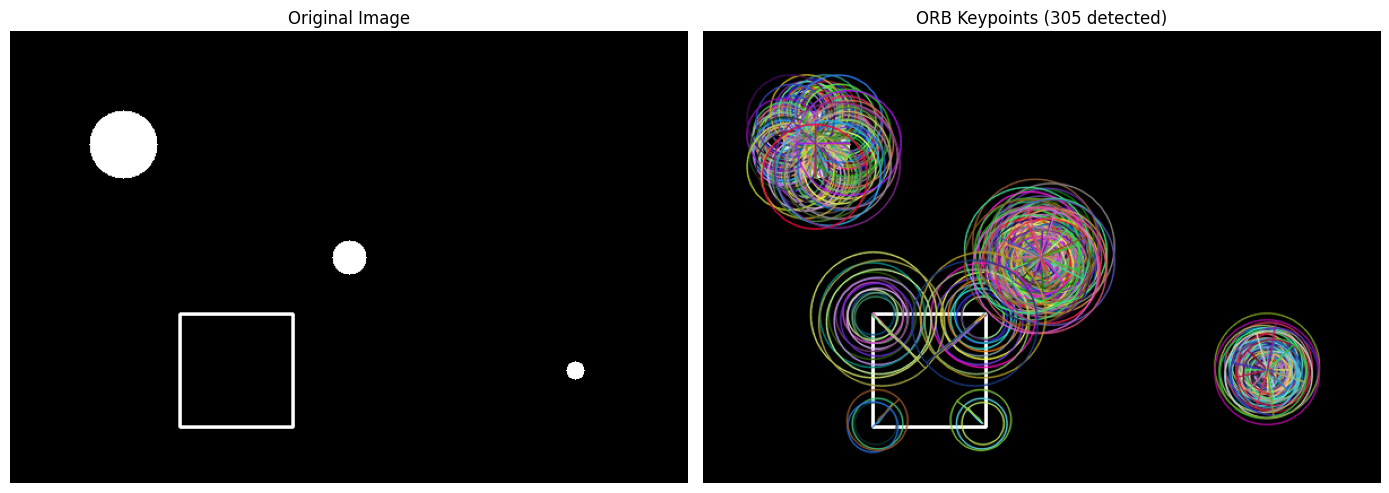


ORB Results:
  Keypoints: 305
  Descriptor size: (305, 32)
  Descriptor type: uint8


In [5]:
# ORB: Free, fast, open-source alternative
orb = cv2.ORB_create(nfeatures=500)

keypoints_orb, descriptors_orb = orb.detectAndCompute(test_img, None)

orb_img = cv2.drawKeypoints(test_img, keypoints_orb, None,
                             flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(test_img, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(orb_img, cv2.COLOR_BGR2RGB) if len(orb_img.shape) == 3 else orb_img, cmap='gray')
axes[1].set_title(f'ORB Keypoints ({len(keypoints_orb)} detected)')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print(f"\nORB Results:")
print(f"  Keypoints: {len(keypoints_orb)}")
print(f"  Descriptor size: {descriptors_orb.shape if descriptors_orb is not None else 'None'}")
print(f"  Descriptor type: {descriptors_orb.dtype}")

## Section 5: Comparison of Descriptors

In [6]:
import time

# Prepare detectors
detectors = {
    'ORB': cv2.ORB_create(nfeatures=500),
}

if sift is not None:
    detectors['SIFT'] = sift

if surf is not None:
    detectors['SURF'] = surf

# Performance comparison
print("\nDescriptor Comparison on " + str(test_img.shape) + " image:")
print("-" * 80)
print(f"{'Method':<15} {'Keypoints':<15} {'Descriptor Size':<15} {'Time (ms)':<15}")
print("-" * 80)

for name, detector in detectors.items():
    start = time.time()
    kp, des = detector.detectAndCompute(test_img, None)
    elapsed = (time.time() - start) * 1000
    
    desc_size = des.shape[1] if des is not None else 0
    print(f"{name:<15} {len(kp):<15} {desc_size:<15} {elapsed:<15.3f}")

print("\nCharacteristics:")
print("  SIFT: Robust, slow, large descriptors (128D)")
print("  SURF: Balanced, medium speed, medium descriptors (64D)")
print("  ORB:  Fast, free, compact descriptors (256 bits)")


Descriptor Comparison on (400, 600) image:
--------------------------------------------------------------------------------
Method          Keypoints       Descriptor Size Time (ms)      
--------------------------------------------------------------------------------
ORB             305             32              7.623          
SIFT            32              128             98.925         

Characteristics:
  SIFT: Robust, slow, large descriptors (128D)
  SURF: Balanced, medium speed, medium descriptors (64D)
  ORB:  Fast, free, compact descriptors (256 bits)


## Section 6: Keypoint Properties


ORB Keypoint Analysis:
------------------------------------------------------------
Keypoint Sizes:
  Min: 31.00, Max: 111.08, Mean: 55.71

Keypoint Angles (degrees):
  Min: 0.00°, Max: 359.19°

Keypoint Responses:
  Min: -0.00, Max: 0.06

Octaves (scale levels):
  Range: 0 to 7


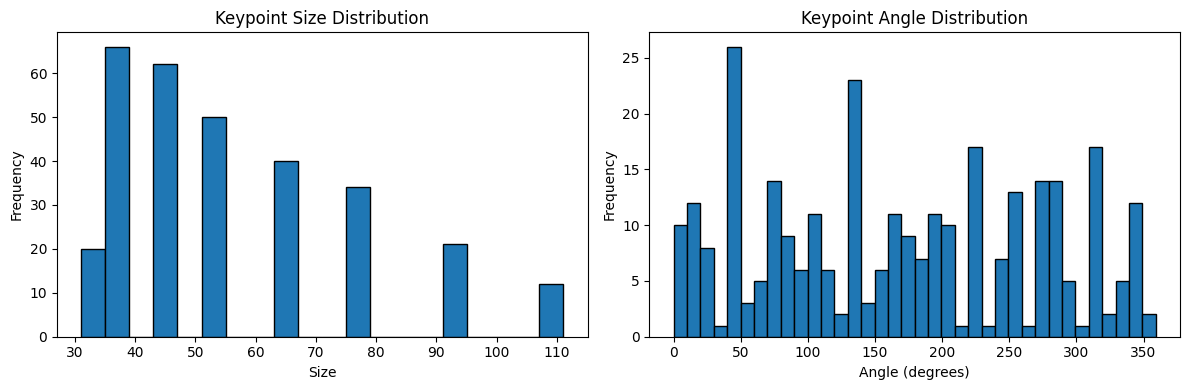

In [7]:
# Analyze keypoint properties
print("\nORB Keypoint Analysis:")
print("-" * 60)

# Extract properties
sizes = np.array([kp.size for kp in keypoints_orb])
angles = np.array([kp.angle for kp in keypoints_orb])
responses = np.array([kp.response for kp in keypoints_orb])
octaves = np.array([kp.octave for kp in keypoints_orb])

print(f"Keypoint Sizes:")
print(f"  Min: {sizes.min():.2f}, Max: {sizes.max():.2f}, Mean: {sizes.mean():.2f}")
print(f"\nKeypoint Angles (degrees):")
print(f"  Min: {angles.min():.2f}°, Max: {angles.max():.2f}°")
print(f"\nKeypoint Responses:")
print(f"  Min: {responses.min():.2f}, Max: {responses.max():.2f}")
print(f"\nOctaves (scale levels):")
print(f"  Range: {octaves.min():.0f} to {octaves.max():.0f}")

# Visualize size and angle distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sizes, bins=20, edgecolor='black')
axes[0].set_title('Keypoint Size Distribution')
axes[0].set_xlabel('Size')
axes[0].set_ylabel('Frequency')

axes[1].hist(angles, bins=36, edgecolor='black')
axes[1].set_title('Keypoint Angle Distribution')
axes[1].set_xlabel('Angle (degrees)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Section 7: Key Takeaways

1. **Scale Space**: Gaussian pyramid and Difference of Gaussians
2. **SIFT**: Most robust, slower, large descriptors
3. **SURF**: Good balance of speed and robustness
4. **ORB**: Fastest, free, uses FAST+BRIEF, binary descriptors
5. **Trade-offs**: 
   - Robustness: SIFT > SURF > ORB
   - Speed: ORB > SURF > SIFT
   - Size: ORB < SURF < SIFT
6. **Next week**: Feature matching between images

## Exercises

1. Compare descriptor matching between SIFT/SURF/ORB on scaled images.
2. Analyze how nfeatures parameter affects ORB performance.
3. Test detectors on rotated/transformed versions of same image.
4. Implement a descriptor distance metric and compare similarity.